In [6]:
import pandas as pd

df_data = pd.read_csv('IDSData.csv')
df_series = pd.read_csv('IDSSeries.csv')

lac_data = df_data[df_data['Country Name'].isin(['Brazil', 'Mexico', 'Argantina', 'Colombia', 'Peru'])]

print(lac_data.head())


     Country Name Country Code  \
2996       Brazil          BRA   
2997       Brazil          BRA   
2998       Brazil          BRA   
2999       Brazil          BRA   
3000       Brazil          BRA   

                                         Indicator Name Indicator Code  \
2996  Average grace period on new external debt comm...    DT.GPA.DPPG   
2997  Average grace period on new external debt comm...    DT.GPA.OFFT   
2998  Average grace period on new external debt comm...    DT.GPA.PRVT   
2999  Average grant element on new external debt com...    DT.GRE.DPPG   
3000  Average grant element on new external debt com...    DT.GRE.OFFT   

         1970     1971     1972     1973     1974     1975  ...     2017  \
2996   3.4321   3.7394   3.6206   3.9078   3.6926   2.6506  ...   6.3816   
2997   5.6240   6.0322   5.2322   4.7361   3.8111   4.6896  ...   4.5118   
2998   2.2442   2.2015   2.4618   3.5578   3.6571   2.1495  ...   8.6131   
2999  19.0173  15.1950  14.3322   7.0148   0.5

In [7]:
year_cols = [str(year) for year in range(1970, 2024)]
df_melted = lac_data.melt(id_vars=['Country Name', 'Indicator Name'],
                          value_vars=year_cols,
                          var_name='Year', value_name='Amount')

df_melted['Year'] = pd.to_numeric(df_melted['Year'])


In [8]:
df_cleaned = lac_data.dropna(axis=0, how='all', subset=year_cols)

df_cleaned[year_cols] = df_cleaned[year_cols].ffill(axis=1)

df_cleaned = df_cleaned.fillna(0)

print(f"Clear after data missing: {len(lac_data) - len(df_cleaned)} columns")


Clear after data missing: 0 columns


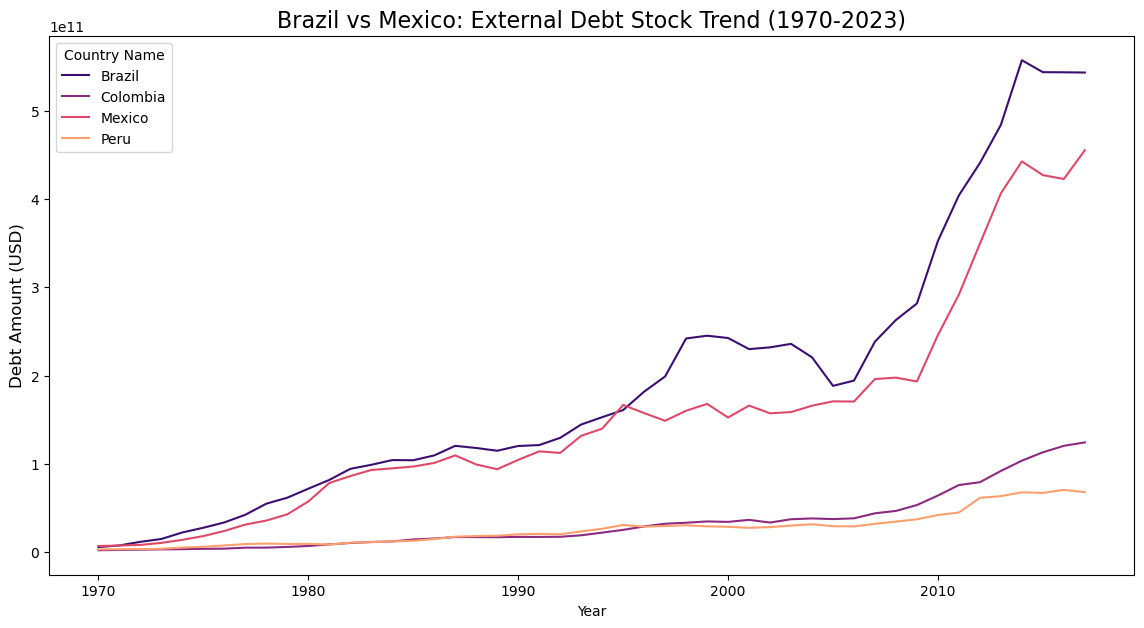

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_melted[df_melted['Indicator Name'].str.contains('External debt stocks, total')],
             x='Year', y='Amount', hue='Country Name', palette='magma')

plt.title('Brazil vs Mexico: External Debt Stock Trend (1970-2023)', fontsize=16)
plt.ylabel('Debt Amount (USD)', fontsize=12)
plt.savefig('debt_comparison_idb.png')
plt.show()


C:\Users\hüseyin\AppData\Local\Temp\ipykernel_13228\2928470215.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis', legend=False)


ML specific charts 'ml_feature_importance.png' and 'ml_model_accuracy.png' generated.


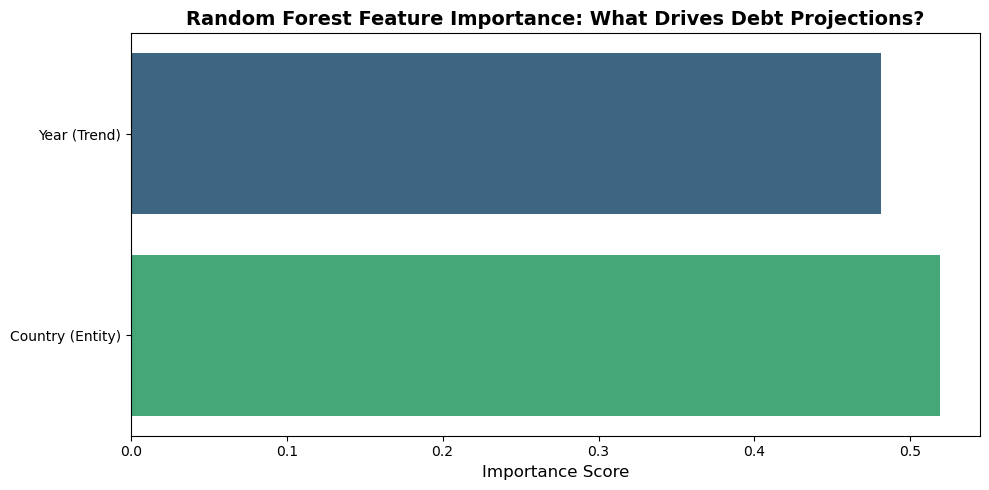

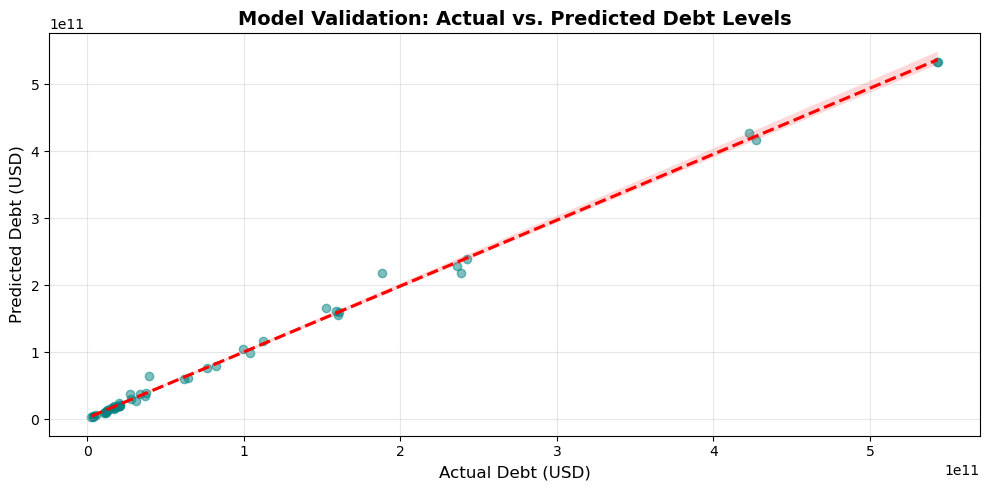

In [10]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('IDSData.csv')
indicator_code = 'DT.DOD.DECT.CD' # External debt stocks, total
target_df = df[df['Indicator Code'] == indicator_code].copy()

# Focus on LAC countries
lac_countries = ['Brazil', 'Mexico', 'Argentina', 'Colombia', 'Peru', 'Chile', 'Ecuador']
target_df = target_df[target_df['Country Name'].isin(lac_countries)]

# Prepare training data
year_cols = [str(year) for year in range(1970, 2023)]
df_melted = target_df.melt(id_vars=['Country Name'], value_vars=year_cols, var_name='Year', value_name='Debt')
df_melted['Year'] = pd.to_numeric(df_melted['Year'])
df_melted = df_melted.dropna(subset=['Debt'])

# Encoding
df_melted['Country_Code'] = df_melted['Country Name'].astype('category').cat.codes

# Train Model
X = df_melted[['Year', 'Country_Code']]
y = df_melted['Debt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# --- Visualization 1: Feature Importance ---
plt.figure(figsize=(10, 5))
importances = rf_model.feature_importances_
feature_names = ['Year (Trend)', 'Country (Entity)']
sns.barplot(x=importances, y=feature_names, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance: What Drives Debt Projections?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('ml_feature_importance.png')

# --- Visualization 2: Prediction Accuracy (Actual vs Predicted) ---
y_pred = rf_model.predict(X_test)
plt.figure(figsize=(10, 5))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red', 'ls':'--'})
plt.title('Model Validation: Actual vs. Predicted Debt Levels', fontsize=14, fontweight='bold')
plt.xlabel('Actual Debt (USD)', fontsize=12)
plt.ylabel('Predicted Debt (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ml_model_accuracy.png')

print("ML specific charts 'ml_feature_importance.png' and 'ml_model_accuracy.png' generated.")
